# Federated normative modeling (model extension)

In multi-site neuroimaging studies, data often cannot leave the hospital or institution where it was collected, due to privacy regulations such as GDPR. **Federated learning (FL)** addresses this constraint: each site trains a model locally and shares only the trained model parameters; never the raw data.

This tutorial demonstrates a FL workflow for normative modeling using PCNtoolkit. For more details you can read the paper below:

> Kia SM, Huijsdens H, Rutherford S, de Boer A, Dinga R, Wolfers T, et al. (2022)  
> *Closing the life-cycle of normative modeling using federated hierarchical Bayesian regression.*  
> PLoS ONE 17(12): e0278776. https://doi.org/10.1371/journal.pone.0278776

## What we will do

**Non-FL model**

1. *Fit a model* on all data together (let's call it *baseline model* as later we will compare it with the extended model produced from the FL workflow)

**FL model**

2. *Split* the data into a large central dataset and two smaller ones
3. *Fit a central model* on the central dataset only
4. *Extend* the central model to each of the two smaller datasets

**Comparison FL vs non-FL model**

5. *Compare* the extended model to the baseline model

**Comparison FL vs location 1 model**

6. *Compare* the extended model to local model trained only on Location 1


## The functions that we will use

| Function | Role |
|---|---|
| `NormativeModel.fit_predict()` | Fit and predict the baseline and central model |
| `NormativeModel.extend_predict()` | Extend the central model with data from a remote location + synthetic data (generated from the central model) and then predict on the test data from a remote location. |

## Imports


In [2]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormalLikelihood,
    NormativeModel,
    NormData,
    load_fcon1000,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

## Load data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset that is included in PCNtoolkit. This dataset contains derived structural MRI phenotypes from 1,078 subjects collected across 23 sites, including cortical thickness measures, subcortical and ventricular volumes, and global brain-volume estimates.

For this tutorial, we select a single response variable: `rh_MeanThickness_thickness` which is the global mean cortical thickness in the right hemisphere.


In [3]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select only the white matter hypointensities feature
#features_to_model = ["WM-hypointensities"]
features_to_model = ["rh_MeanThickness_thickness"]
norm_data = norm_data.sel(
    {"response_vars": features_to_model}
)

# Show all available sites
all_sites = np.unique(
    norm_data.batch_effects.sel(
        batch_effect_dims="site"
    ).values
)
print(
    f"Total sites: {len(all_sites)}"
)
print(f"Sites: {all_sites}")

Total sites: 23
Sites: ['AnnArbor_a' 'AnnArbor_b' 'Atlanta' 'Baltimore' 'Bangor' 'Beijing_Zang'
 'Berlin_Margulies' 'Cambridge_Buckner' 'Cleveland' 'ICBM' 'Leiden_2180'
 'Leiden_2200' 'Milwaukee_b' 'Munchen' 'NewYork_a' 'NewYork_a_ADHD'
 'Newark' 'Oulu' 'Oxford' 'PaloAlto' 'Pittsburgh' 'Queensland'
 'SaintLouis']


## Split data

We split the data into:

- A large central dataset (19 sites)
- Two smaller datasets (each dataset has 2 sites) 

In a FL scenario the large model would be owned by a central location (e.g., a hospital in the Netherlands) and the smaller ones by remote locations 1 and 2 (e.g, a hospital in France and in the USA). All these locations don't want to share their data due to privacy. For this reason, they use the FL workflow.


In [4]:
# Pick 2 sites for each remote location
location1_sites = list(all_sites[:2])
location2_sites = list(all_sites[2:4])
print(
    f"Location 1 sites: {location1_sites}"
)
print(
    f"Location 2 sites: {location2_sites}"
)

# Split off location 1
location1_data, remaining = (
    norm_data.batch_effects_split(
        {"site": location1_sites},
        names=("location1", "remaining"),
    )
)

# Split off location 2 
location2_data, central_data = (
    remaining.batch_effects_split(
        {"site": location2_sites},
        names=("location2", "central"),
    )
)

# Create train/test splits for each location
train_central, test_central = (
    central_data.train_test_split()
)
train_location1, test_location1 = (
    location1_data.train_test_split()
)
train_location2, test_location2 = (
    location2_data.train_test_split()
)

# Global train/test for the baseline model
train_all, test_all = (
    norm_data.train_test_split()
)

print(
    f"\nCentral: "
    f"{train_central.X.shape[0]} train, "
    f"{test_central.X.shape[0]} test"
)
print(
    f"Location 1: "
    f"{train_location1.X.shape[0]} train, "
    f"{test_location1.X.shape[0]} test"
)
print(
    f"Location 2: "
    f"{train_location2.X.shape[0]} train, "
    f"{test_location2.X.shape[0]} test"
)
print(
    f"All data: "
    f"{train_all.X.shape[0]} train, "
    f"{test_all.X.shape[0]} test"
)

Location 1 sites: [np.str_('AnnArbor_a'), np.str_('AnnArbor_b')]
Location 2 sites: [np.str_('Atlanta'), np.str_('Baltimore')]

Central: 776 train, 195 test
Location 1: 44 train, 12 test
Location 2: 40 train, 11 test
All data: 862 train, 216 test


## Visualize the data


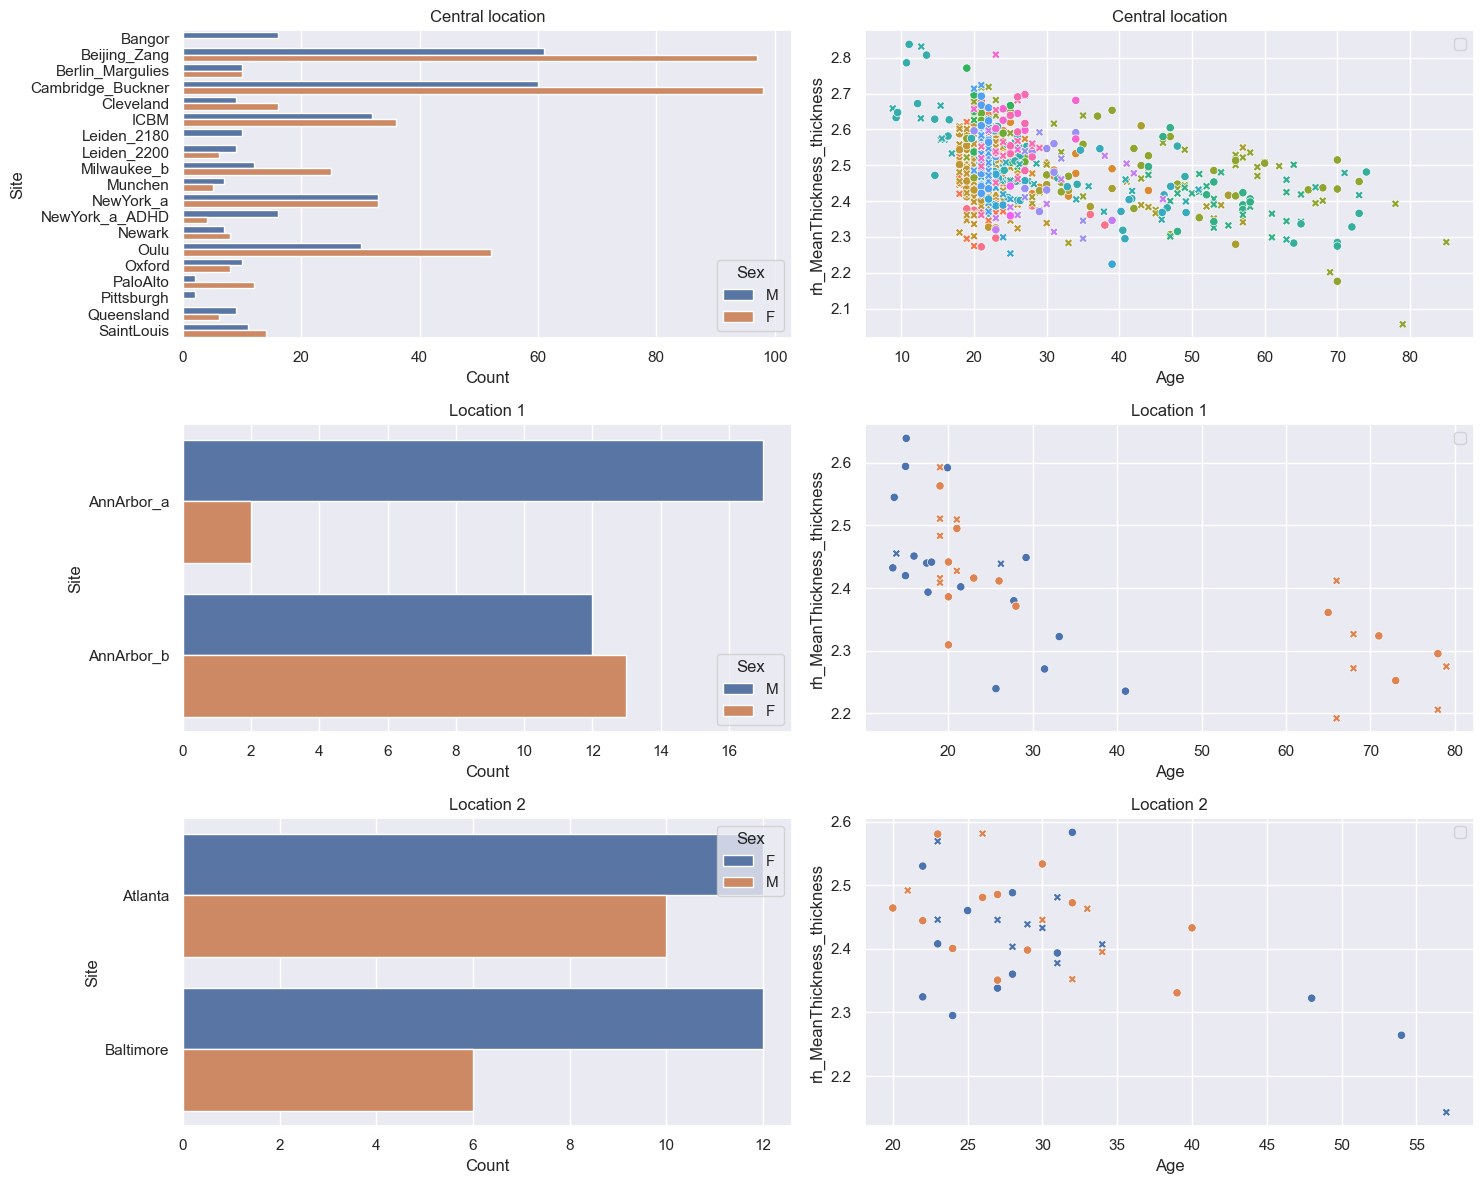

In [5]:
feature = features_to_model[0]
datasets = {
    "Central location": train_central,
    "Location 1": train_location1,
    "Location 2": train_location2,
}

fig, axes = plt.subplots(
    3, 2, figsize=(15, 12)
)

# for every dataset
for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(
        f"{name}"
    )
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(
        f"{name}"
    )
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

## Configure the HBR model

We define a shared model configuration that will be used for both baseline and FL model. This ensures a fair comparison. We use a Normal likelihood HBR with B-spline basis functions.


In [6]:
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template",
    cores=16,
    progressbar=False,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=likelihood,
)


---

## Part 1: Baseline model

In a non-FL scenario, we would pool all the data from all the 23 sites into a single dataset and train one model.


In [7]:
baseline_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir=(
        "resources/federated/baseline"
    ),
    inscaler="standardize",
    outscaler="standardize",
);

# Use the data from all 23 sites, before any splitting happened.
baseline_model.fit_predict(train_all, test_all);

## Part 2: FL with `extend()`

Now we simulate the FL scenario. None of the locations (central, location 1 and 2) share their data with each other. Only model parameters are exchanged.

### Step 1: Train the central model

The central location trains an HBR model using only its own 19 sites.


In [8]:
central_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir=(
        "resources/federated/central"
    ),
    inscaler="standardize",
    outscaler="standardize",
);

central_model.fit_predict(train_central, test_central);

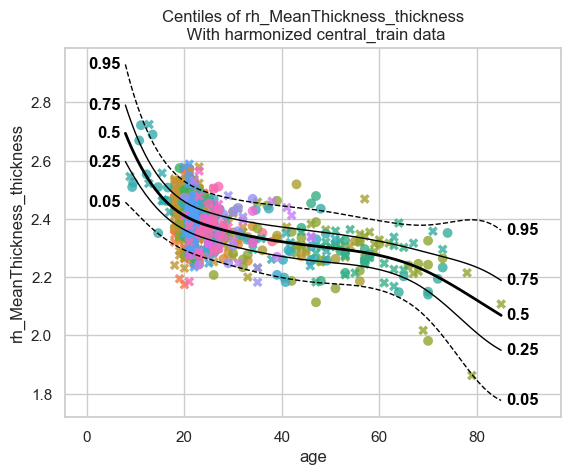

In [9]:
# Centile curves for the central model
plot_centiles_advanced(
    central_model,
    scatter_data=train_central,
    batch_effects="all",
    show_legend=False
);

### Step 2: Extend the central model to remote locations

Location 1 receives the central model json files that are saved in `resources/federated/central` and calls `extend_predict()` locally using its own private data.

`extend_predict()` runs both `extend()` and `predict()`. `extend()` synthesizes data from the central model's learned distribution, merges it with the real local data, and refits a full model.

No real data is exchanged only model parameters.


In [10]:
# Location 1 loads the central model from disk
central_model = NormativeModel.load("resources/federated/central")

# Location 1 extends the central model
# with their private data.
extended_location_1_model = central_model.extend_predict(
    train_location1,
    test_location1,
    save_dir=(
        "resources/federated/extended_location_1"
    ),
);

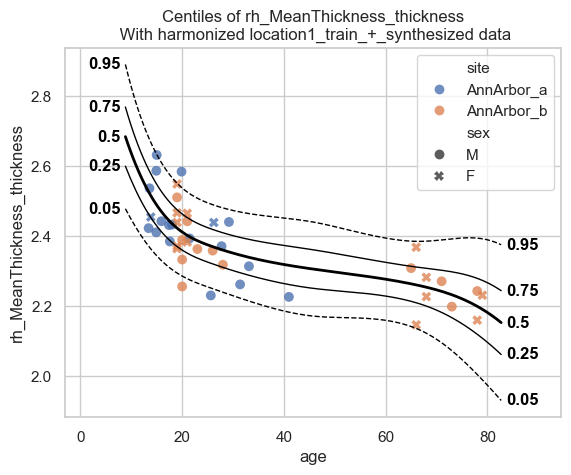

In [11]:
# Visualize the extended model
plot_centiles_advanced(
    extended_location_1_model,
    scatter_data=train_location1,
    batch_effects="all",
)

The extended model from location 1 knows about both the central sites (via synthetic data) and its own local sites. Notice that it retains the characteristic shape for the centiles.

Now location 1 shares its extended model parameters with location 2. Location 2 extends the model further with their own data.

In [12]:
# Location 2 loads the extended model from disk
extended_location_1_model = NormativeModel.load("resources/federated/extended_location_1")

# Location 2 extends the model
# with their private data.
extended_location_1_and_2_model = extended_location_1_model.extend_predict(
    train_location2,
    test_location2,
    save_dir=(
        "resources/federated/extended_location_1_and_2"
    ),
)

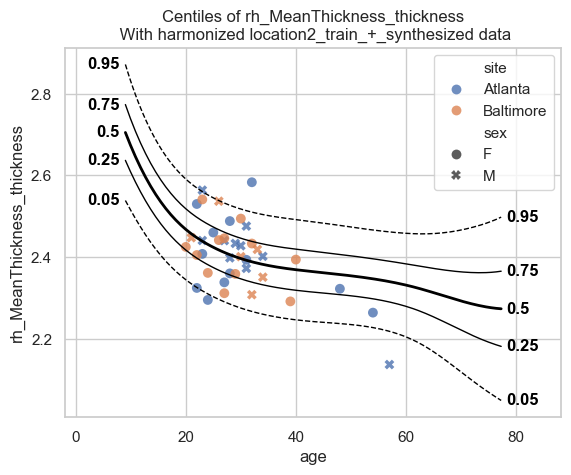

In [13]:
plot_centiles_advanced(
    extended_location_1_and_2_model,
    scatter_data=train_location2,
    batch_effects="all",
)

The extended model from location 2 knows about both the central and location 1 sites (via synthetic data) and its own local sites.

---

## Extended vs baseline model

We now compare the 2 models:

- **baseline**: all data were in one location
- **extended**: data were split in 3 locations

=== baseline model ===


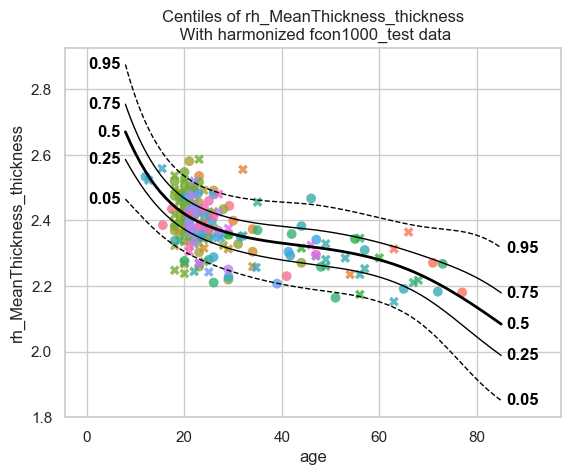


=== Extended model ===


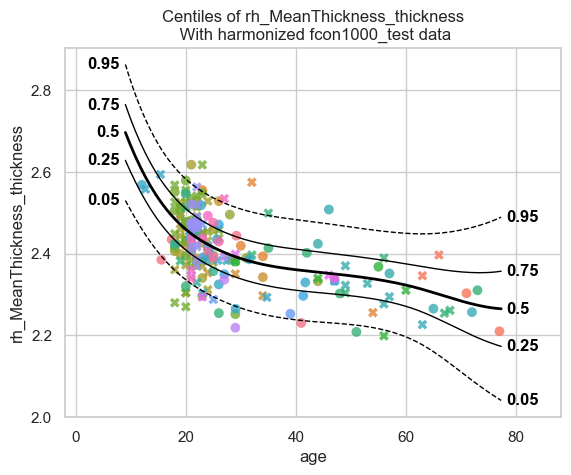

In [14]:
# baseline model centiles
print("=== baseline model ===")
plot_centiles_advanced(
    baseline_model,
    scatter_data=test_all,
    batch_effects="all",
    show_legend=False
)

# Extended model centiles
print("\n=== Extended model ===")
plot_centiles_advanced(
    extended_location_1_and_2_model,
    scatter_data=test_all,
    batch_effects="all",
    show_legend=False
)

## Conclusions

The two models perform very similarly. So the FL workflow, where the data are different locations. performs as similar to
the baseline workflow, where all the data are in one location.

---

## Extended vs a local model trained only on Location 1

Finally, for didactic purposes, we generate a model using only the data from location 1. This is a tiny dataset, so we should not expect this to work well. 


In [ ]:
location_1_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir=(
        "resources/federated/location_1"
    ),
    inscaler="standardize",
    outscaler="standardize",
);

# Use the data from location 1 only (2 sites)
location_1_model.fit_predict(train_location1, test_location1);

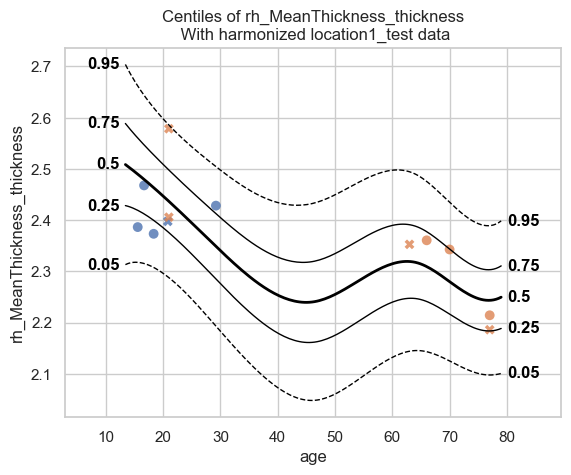

In [ ]:
plot_centiles_advanced(
    location_1_model,
    scatter_data=test_location1,
    batch_effects="all",
    show_legend=False
)

As we anticipated this model does a terrible job in fitting the data and yields a biologically implausible shape for cortical thickness data. This is due to two factors: first the small size of the training dataset, and second the fact that it does not provide good coverage across the age range. The gap in the data from 30-60 years means that the model must interpolate wildly. In contrast, the extended models above retain information from the original dataset (via the model coefficients), and therefore retain the characteristic shape.